In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv")

In [3]:
df.index.min(), df.index.max()

(0, 26135)

In [4]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')



Origin 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1073.66 | RMSE=1308.81 | MAPE=7.76%

Origin 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=872.25 | RMSE=1127.42 | MAPE=6.48%

Origin 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=2175.05 | RMSE=2748.27 | MAPE=23.10%

Origin 4/6 — 2025-10-01
  Train rows: 23928 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=680.68 | RMSE=861.17 | MAPE=8.87%

Origin 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=411.10 | RMSE=563.52 | MAPE=4.96%

Origin 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=332.77 | RMSE=433.10 | MAPE=3.77%

SARIMA+RF Hybrid Walk-Forward Results
MAE  = 920.24 MW
RMSE = 1393.75 MW
MAPE = 9.10 %

Monthly metrics by origin:
  origin_month  n_hours          MAE  

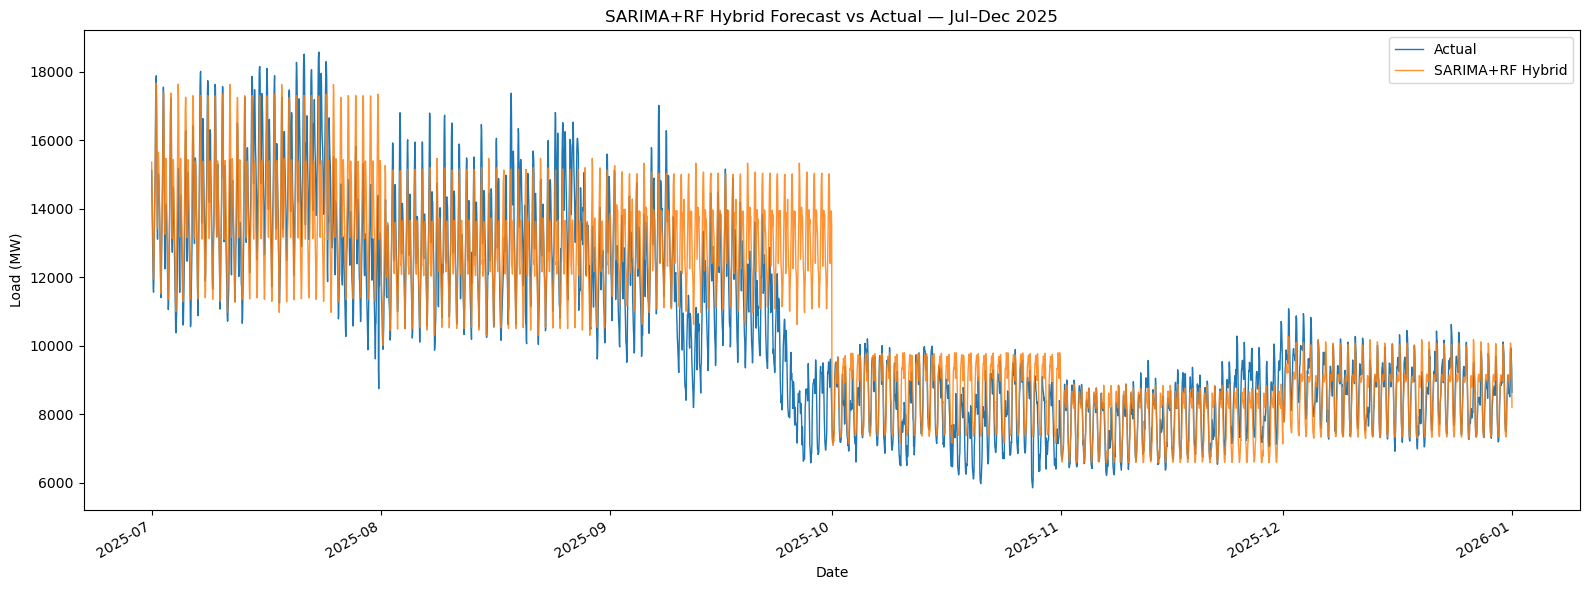

In [6]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"
y = df[target_col]

origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

# Calendar feature builder — same as your RF setup
def make_calendar_features(index):
    df_feat = pd.DataFrame(index=index)
    df_feat["hour"] = index.hour
    df_feat["dow"] = index.dayofweek
    df_feat["month"] = index.month
    df_feat["year"] = index.year
    df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
    df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)
    df_feat["dow_sin"] = np.sin(2 * np.pi * df_feat["dow"] / 7)
    df_feat["dow_cos"] = np.cos(2 * np.pi * df_feat["dow"] / 7)
    df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12)
    df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12)
    
    return df_feat

preds_hybrid = []
actuals_hybrid = []
monthly_metrics = []

# ============================================================
# 2) MONTHLY WALK-FORWARD LOOP
# ============================================================
for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/{len(origins)} — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)

    train = y.loc[: origin - pd.Timedelta(hours=1)].dropna()
    actual_month = y.loc[origin:month_end].dropna()

    if len(actual_month) == 0:
        print("  Skipped — empty test block")
        continue

    print(f"  Train rows: {len(train)} | Test rows: {len(actual_month)}")

    # -------------------------
    # STEP 1: Fit SARIMA on train
    # -------------------------
    sarima_model = SARIMAX(
        train,
        order=(2, 0, 1),
        seasonal_order=(0, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima_model.fit(disp=False)

    # SARIMA forecast for test month
    sarima_forecast = sarima_fit.forecast(steps=len(actual_month))
    sarima_forecast.index = actual_month.index

    # SARIMA in-sample fitted values for train
    sarima_insample = sarima_fit.fittedvalues

    # -------------------------
    # STEP 2: Compute train residuals
    # -------------------------
    residuals_train = train - sarima_insample
    residuals_train = residuals_train.dropna()

    # -------------------------
    # STEP 3: Fit RF on residuals using calendar features
    # -------------------------
    X_train = make_calendar_features(residuals_train.index)
    y_train_resid = residuals_train.values

    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train_resid)

    # -------------------------
    # STEP 4: Predict residuals for test month
    # -------------------------
    X_test = make_calendar_features(actual_month.index)
    rf_resid_forecast = rf_model.predict(X_test)
    rf_resid_forecast = pd.Series(rf_resid_forecast, index=actual_month.index)

    # -------------------------
    # STEP 5: Combine
    # -------------------------
    pred_month = sarima_forecast + rf_resid_forecast

    preds_hybrid.append(pred_month)
    actuals_hybrid.append(actual_month)

    # -------------------------
    # Monthly metrics
    # -------------------------
    mae_m = np.mean(np.abs(actual_month - pred_month))
    rmse_m = np.sqrt(np.mean((actual_month - pred_month) ** 2))
    mape_m = np.mean(np.abs((actual_month - pred_month) / actual_month)) * 100

    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(actual_month),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    print(f"  Done — {len(actual_month)} hours forecasted")
    print(f"  Monthly MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%")

# ============================================================
# 3) OVERALL METRICS
# ============================================================
pred_hybrid = pd.concat(preds_hybrid).sort_index()
actual_hybrid = pd.concat(actuals_hybrid).sort_index()

mae = np.mean(np.abs(actual_hybrid - pred_hybrid))
rmse = np.sqrt(np.mean((actual_hybrid - pred_hybrid) ** 2))
mape = np.mean(np.abs((actual_hybrid - pred_hybrid) / actual_hybrid)) * 100

print(f"\nSARIMA+RF Hybrid Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 4) MONTHLY METRICS TABLE
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)
print("\nMonthly metrics by origin:")
print(monthly_metrics_df)

# ============================================================
# 5) SAVE
# ============================================================
monthly_metrics_df.to_csv("hybrid_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_hybrid,
    "predicted": pred_hybrid
})
pred_vs_actual_df.to_csv("hybrid_walkforward_predictions.csv")

# ============================================================
# 6) PLOT
# ============================================================
fig_forecast, ax = plt.subplots(figsize=(16, 6))

ax.plot(actual_hybrid.index, actual_hybrid.values, label="Actual", linewidth=1.0)
ax.plot(pred_hybrid.index, pred_hybrid.values, label="SARIMA+RF Hybrid", linewidth=1.0, alpha=0.85)

ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("SARIMA+RF Hybrid Forecast vs Actual — Jul–Dec 2025")
ax.legend()

fig_forecast.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 7) MLFLOW LOGGING
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

with mlflow.start_run(run_name="Hybrid_SARIMA_RF_walkforward_monthly_final"):
    mlflow.log_param("model", "SARIMA+RF Hybrid")
    mlflow.log_param("sarima_order", "(2,0,1)")
    mlflow.log_param("sarima_seasonal_order", "(0,1,1,24)")
    mlflow.log_param("rf_n_estimators", 100)
    mlflow.log_param("rf_max_depth", 10)
    mlflow.log_param("rf_min_samples_split", 5)
    mlflow.log_param("rf_min_samples_leaf", 2)
    mlflow.log_param("rf_max_features", 0.8)
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")
    mlflow.log_param("hybrid_strategy", "sarima_residual_correction")

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    mlflow.log_artifact("hybrid_monthly_metrics.csv")
    mlflow.log_artifact("hybrid_walkforward_predictions.csv")

    fig_forecast.savefig("hybrid_forecast.png")
    mlflow.log_artifact("hybrid_forecast.png")

In [4]:
df['lag_744']=df['load'].shift(744)

Using features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'hour', 'day_of_week', 'month', 'year']

Origin 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1386.15 | RMSE=1719.20 | MAPE=9.41%

Origin 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1073.78 | RMSE=1341.07 | MAPE=8.64%

Origin 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=1756.77 | RMSE=2039.47 | MAPE=15.66%

Origin 4/6 — 2025-10-01
  Train rows: 23928 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=431.84 | RMSE=552.60 | MAPE=5.50%

Origin 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=401.33 | RMSE=566.45 | MAPE=4.74%

Origin 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=357.34 | RMSE=465.03 | MAPE=3.96%

Random Forest Walk-Forw

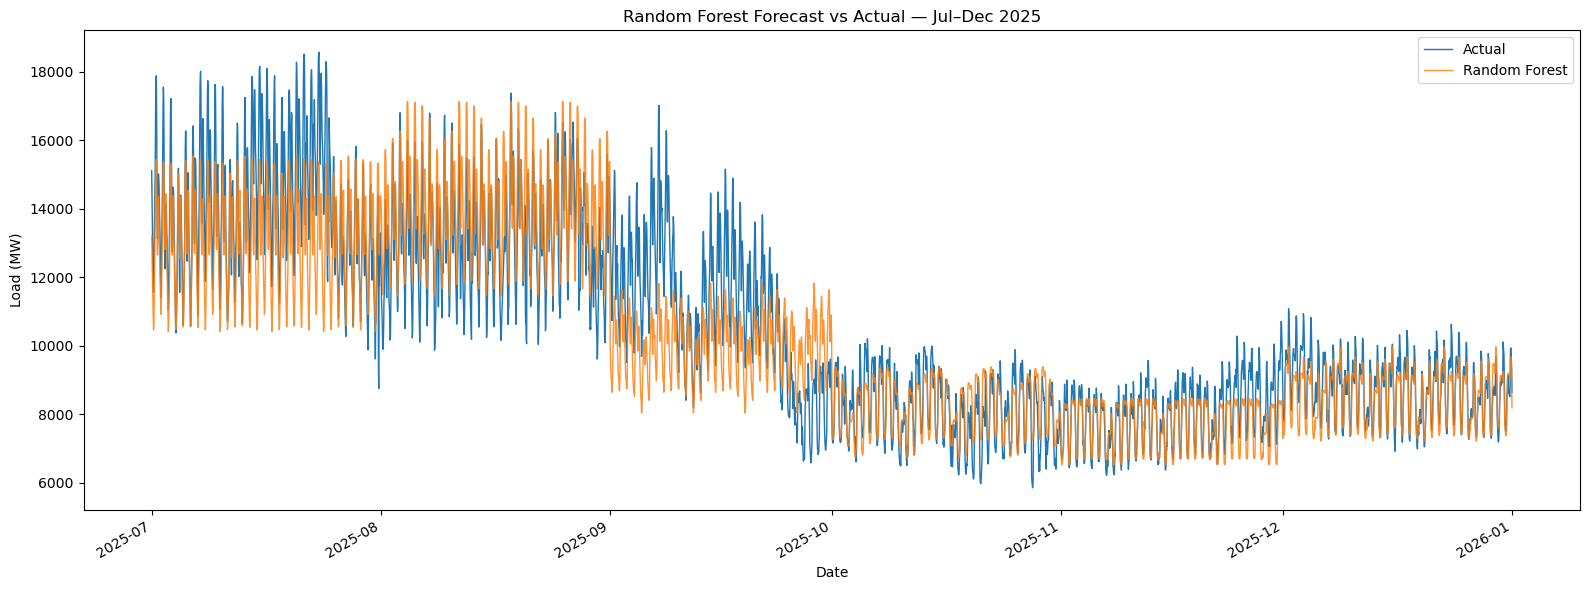

🏃 View run RF_walkforward_monthly_calendar_only at: http://127.0.0.1:5000/#/experiments/531580567308328190/runs/0db74b238fd044de99dd08a56b6c54ad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/531580567308328190


In [6]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

# fixed RF config
rf_params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": 0.8
}

# ============================================================
# 2) CALENDAR FEATURES ONLY
#    adjust names if needed
# ============================================================
feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]

feature_cols = [c for c in feature_cols if c in df.columns]
print("Using features:", feature_cols)

# ============================================================
# 3) MONTHLY WALK-FORWARD
# ============================================================
preds_rf = []
actuals_rf = []
monthly_metrics = []

for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/{len(origins)} — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)

    train_df = df.loc[: origin - pd.Timedelta(hours=1)].copy()
    test_df = df.loc[origin:month_end].copy()

    train_df = train_df.dropna(subset=feature_cols + [target_col])
    test_df = test_df.dropna(subset=feature_cols + [target_col])

    if len(test_df) == 0:
        print("  Skipped — empty test block")
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    print(f"  Train rows: {len(train_df)} | Test rows: {len(test_df)}")

    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)

    pred_month = pd.Series(model.predict(X_test), index=test_df.index)
    actual_month = y_test.copy()

    preds_rf.append(pred_month)
    actuals_rf.append(actual_month)

    mae_m = mean_absolute_error(actual_month, pred_month)
    rmse_m = np.sqrt(mean_squared_error(actual_month, pred_month))
    mape_m = np.mean(np.abs((actual_month - pred_month) / actual_month)) * 100

    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(actual_month),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    print(f"  Done — {len(actual_month)} hours forecasted")
    print(f"  Monthly MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%")

# ============================================================
# 4) OVERALL METRICS
# ============================================================
pred_rf = pd.concat(preds_rf).sort_index()
actual_rf = pd.concat(actuals_rf).sort_index()

mae = mean_absolute_error(actual_rf, pred_rf)
rmse = np.sqrt(mean_squared_error(actual_rf, pred_rf))
mape = np.mean(np.abs((actual_rf - pred_rf) / actual_rf)) * 100

print(f"\nRandom Forest Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 5) MONTHLY METRICS TABLE
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)

print("\nMonthly metrics by origin:")
print(monthly_metrics_df)

# ============================================================
# 6) SAVE TABLES
# ============================================================
monthly_metrics_df.to_csv("rf_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_rf,
    "predicted": pred_rf
})
pred_vs_actual_df.to_csv("rf_walkforward_predictions.csv")

# ============================================================
# 7) PLOT
# ============================================================
fig_forecast, ax = plt.subplots(figsize=(16, 6))

ax.plot(actual_rf.index, actual_rf.values, label="Actual", linewidth=1.0)
ax.plot(pred_rf.index, pred_rf.values, label="Random Forest", linewidth=1.0, alpha=0.85)

ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Random Forest Forecast vs Actual — Jul–Dec 2025")
ax.legend()

fig_forecast.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 8) MLFLOW
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

with mlflow.start_run(run_name="RF_walkforward_monthly_calendar_only"):
    mlflow.log_param("model", "RandomForestRegressor")
    for k, v in rf_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("features", str(feature_cols))
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_style", "direct_non_recursive")
    mlflow.log_param("lag_features_used", False)

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    mlflow.log_artifact("rf_monthly_metrics.csv")
    mlflow.log_artifact("rf_walkforward_predictions.csv")

    fig_forecast.savefig("rf_forecast.png")
    mlflow.log_artifact("rf_forecast.png")

In [4]:
import os
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

os.makedirs("models", exist_ok=True)

target_col = "load"

rf_feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]

rf_params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

train_df = df.dropna(subset=rf_feature_cols + [target_col]).copy()

X_train = train_df[rf_feature_cols]
y_train = train_df[target_col]

rf_final = RandomForestRegressor(**rf_params)
rf_final.fit(X_train, y_train)

joblib.dump(rf_final, "models/rf_final.pkl")
joblib.dump(rf_feature_cols, "models/rf_feature_cols.pkl")

print("Saved RF model to models/rf_final.pkl")

Saved RF model to models/rf_final.pkl


Grid-search training rows: 21720
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best params from one-time GridSearch:
{'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score (neg MAE): -2169.0649

Monthly refit 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 4/6 — 2025-10-01
  Train rows: 23928 | Test rows: 744
  Done — 744 hours forecasted

Monthly refit 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720
  Done — 720 hours forecasted

Monthly refit 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744
  Done — 744 hours forecasted

Random Forest Walk-Forward Results
MAE  = 947.05 MW
RMSE = 1285.15 MW
MAPE = 9.02 %


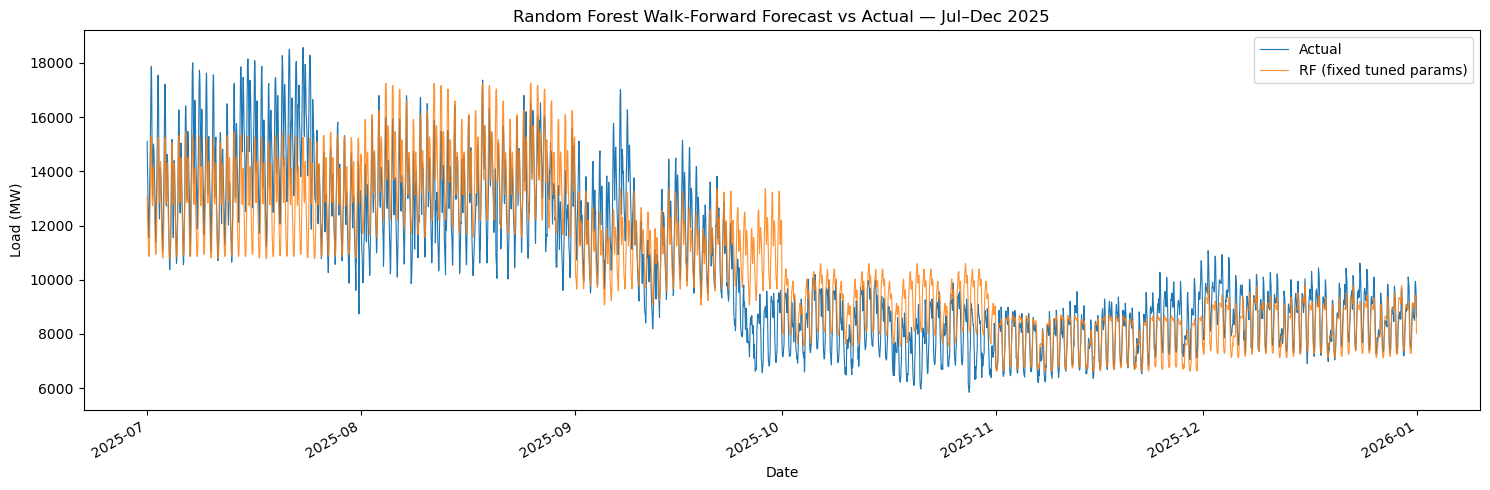

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit



# ── leakage-safe features for monthly block forecasting ───────
feature_cols = [
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'

# ============================================================
# 1) GRID SEARCH ONCE ON PRE-JULY-2025 TRAINING DATA
# ============================================================
grid_train_end = pd.Timestamp("2025-06-30 23:00:00")

grid_train_df = df.loc[:grid_train_end].dropna(
    subset=feature_cols + [target_col]
).copy()

X_grid = grid_train_df[feature_cols]
y_grid = grid_train_df[target_col]

print(f"Grid-search training rows: {len(X_grid)}", flush=True)

param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "min_samples_split": [5],
    "min_samples_leaf": [2],
    "max_features": [0.8]
}

base_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_grid, y_grid)

best_params = grid.best_params_
best_cv_score = grid.best_score_

print("\nBest params from one-time GridSearch:")
print(best_params)
print(f"Best CV score (neg MAE): {best_cv_score:.4f}")

# ============================================================
# 2) MONTHLY WALK-FORWARD WITH FIXED BEST PARAMS
# ============================================================
month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_rf = []
actuals_rf = []

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*60}", flush=True)
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}", flush=True)

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    test_df = df.loc[
        (df.index >= month_origin) & (df.index < next_month_origin)
    ].dropna(subset=feature_cols + [target_col]).copy()

    if len(test_df) == 0:
        print("  Skipped — empty test block", flush=True)
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    model = RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred_month = pd.Series(model.predict(X_test), index=y_test.index)

    preds_rf.append(pred_month)
    actuals_rf.append(y_test)

    print(f"  Train rows: {len(X_train)} | Test rows: {len(X_test)}", flush=True)
    print(f"  Done — {len(y_test)} hours forecasted", flush=True)

pred_rf   = pd.concat(preds_rf).sort_index()
actual_rf = pd.concat(actuals_rf).sort_index()

mae  = np.mean(np.abs(actual_rf - pred_rf))
rmse = np.sqrt(np.mean((actual_rf - pred_rf) ** 2))
mape = np.mean(np.abs((actual_rf - pred_rf) / actual_rf)) * 100

print(f"\nRandom Forest Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 3) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_rf.index, actual_rf.values, label="Actual", linewidth=0.8)
ax.plot(pred_rf.index, pred_rf.values, label="RF (fixed tuned params)", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Random Forest Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
